<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Bibliotecas" data-toc-modified-id="Bibliotecas-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Bibliotecas</a></span></li><li><span><a href="#Funções" data-toc-modified-id="Funções-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Funções</a></span></li><li><span><a href="#Pegando-dados-do-Postgres" data-toc-modified-id="Pegando-dados-do-Postgres-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Pegando dados do Postgres</a></span></li><li><span><a href="#Tratamento-dos-dados" data-toc-modified-id="Tratamento-dos-dados-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Tratamento dos dados</a></span><ul class="toc-item"><li><span><a href="#Retirada-das-variáveis-como-object" data-toc-modified-id="Retirada-das-variáveis-como-object-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Retirada das variáveis como object</a></span></li><li><span><a href="#Retirada-de-variáveis" data-toc-modified-id="Retirada-de-variáveis-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Retirada de variáveis</a></span></li></ul></li><li><span><a href="#Separando-em-teste-e-treino" data-toc-modified-id="Separando-em-teste-e-treino-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Separando em teste e treino</a></span></li><li><span><a href="#Correlação" data-toc-modified-id="Correlação-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Correlação</a></span></li><li><span><a href="#Balanceamento" data-toc-modified-id="Balanceamento-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Balanceamento</a></span></li><li><span><a href="#Modelagem:-Modelo-Logístico" data-toc-modified-id="Modelagem:-Modelo-Logístico-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Modelagem: Modelo Logístico</a></span></li><li><span><a href="#Avaliação" data-toc-modified-id="Avaliação-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Avaliação</a></span></li></ul></div>

# Bibliotecas

In [1]:
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from unidecode import unidecode 

# Funções

In [ ]:
##################
#### WoE e IV ####
##################

def WoE_IV(variavel, rotulo, dados)
df_woe_iv = (pd.crosstab(dados[variavel],dados[rotulo],
                      normalize='columns')
             .assign(woe=lambda dfx: np.log(dfx[1] / dfx[0]))
             .assign(iv=lambda dfx: np.sum(dfx['woe']*
                                           (dfx[1]-dfx[0]))))

print(df_woe_iv)

In [15]:
#################################
###### Top ABS Correlations #####
#################################


def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

In [ ]:
##############################
###### Matriz de confusão ####
##############################

def matriz_confusao(y_real,y_predito,modelo):

### Grafico ###

    tabela=confusion_matrix(y_real,y_predito)

    group_names = ["True Neg","False Pos","False Neg","True Pos"]
    group_counts = ["{0:0.0f}".format(value) for value in
                tabela.flatten()]
    group_percentages = ["{0:.5%}".format(value) for value in
                     tabela.flatten()/np.sum(tabela)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    f = plt.figure()
    f.set_figwidth(8)
    f.set_figheight(8)

    sns.heatmap(tabela, annot=labels, fmt="", cmap='Blues')

### Tabela ###
    Resultados=PrettyTable()
    Resultados.field_names=["Métrica","Resultado"]
    Resultados.title= modelo
    Resultados.align["Métrica"]="l"
    Resultados.align["Resultado"]="r"

    Resultados.add_row(["Acurácia:",round(sklearn.metrics.accuracy_score(y_real,y_predito),2)])
    Resultados.add_row(["Precisão:",round(sklearn.metrics.precision_score(y_real,y_predito),2)])
    Resultados.add_row(["Recall:",round(sklearn.metrics.recall_score(y_real,y_predito),2)])
    Resultados.add_row(["F1-Score:",round(sklearn.metrics.f1_score(y_real,y_predito),2)])

    print(Resultados)
  
    return

# Pegando dados do Postgres

In [2]:
sql = '''
SELECT *
FROM vw_ocorrencia_deslizamento_chuva
'''

database = ''
user = ''
password = ''
host = ''
port = ''

conn = psycopg2.connect(database=database, user=user, password=password, host=host, port=port)

with conn.cursor() as cursor:

    cursor.execute(sql)

    ocorrencia_deslizamento_chuva = cursor.fetchall()

    cols = []
    [cols.append(nm[0]) for nm in cursor.description]

    df = pd.DataFrame(ocorrencia_deslizamento_chuva)
    df.columns = cols

#trata o nome da estacao que pode dar erro por causa de acento e espaços
nome_estacao = df['nome_estacao'].to_list()
new_nome_estacao = [unidecode(nome).replace(" ", "_").replace("'","") for nome in nome_estacao]
df['nome_estacao']= df['nome_estacao'].replace(nome_estacao, new_nome_estacao)

df.head(5)

,indice_pluv,quinzemin,trintamin,umahora,seishoras,dozehoras,vintequatrohoras,quarentaoitohoras,setentaduashoras,noventaseishoras,...,CUBANGO,SANTA ROSA,RIO DO OURO,CARAMUJO,ITAIPU,JURUJUBA,VÁRZEA DAS MOÇAS,ENGENHO DO MATO,BAÍA DE GUANABARA,BAIRRO DE FÁTIMA
0,0.0,0.0,0.0,0.0,3.55974000000000022,4.15242000000000025,4.15242000000000025,4.15242000000000025,4.15242000000000025,4.15242000000000025,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0.5890200000000001,0.98170000000000013,1.57072000000000023,2.75242000000000036,13.00602000000000105,30.50601919677426812,38.99061756570985915,39.58329756570985918,39.58329756570985918,39.58329756570985918,...,0,0,0,0,1,0,0,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,4.15249010954616609,9.88026693815144245,13.26562693815144251,18.65241106657916764,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1533 entries, 0 to 1532
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   indice_pluv               1533 non-null   object        
 1   quinzemin                 1533 non-null   object        
 2   trintamin                 1533 non-null   object        
 3   umahora                   1533 non-null   object        
 4   seishoras                 1533 non-null   object        
 5   dozehoras                 1533 non-null   object        
 6   vintequatrohoras          1533 non-null   object        
 7   quarentaoitohoras         1533 non-null   object        
 8   setentaduashoras          1533 non-null   object        
 9   noventaseishoras          1533 non-null   object        
 10  mes                       1533 non-null   object        
 11  status_indice_pluv        1533 non-null   int64         
 12  status_quinzemin    

In [4]:
pd.options.display.max_rows = None
print('Valores únicos em cada variável: \n')
df.nunique(dropna=False).sort_values()

Valores únicos em cada variável: 



status_trintamin               1
status_mes                     1
status_noventaseishoras        1
status_setentaduashoras        1
status_quarentaoitohoras       1
status_vintequatrohoras        1
status_dozehoras               1
status_seishoras               1
status_umahora                 1
status_quinzemin               1
status_indice_pluv             1
mapeamento                     1
PIRATININGA                    2
BAÍA DE GUANABARA              2
SÃO FRANCISCO                  2
FONSECA                        2
SÃO LOURENÇO                   2
BALDEADOR                      2
CENTRO                         2
MACEIÓ                         2
BARRETO                        2
ENGENHOCA                      2
TENENTE JARDIM                 2
PONTA D'AREIA                  2
MARAVISTA                      2
LARGO DA BATALHA               2
BAIRRO DE FÁTIMA               2
CHARITAS                       2
SANTA ROSA                     2
ENGENHO DO MATO                2
VÁRZEA DAS

# Tratamento dos dados

In [5]:
df_trat= df.copy()

## Retirada das variáveis como object

In [6]:
variaveis_object = ['indice_pluv'
,'quinzemin'            
,'trintamin'            
,'umahora'              
,'seishoras'            
,'dozehoras'            
,'vintequatrohoras'     
,'quarentaoitohoras'    
,'setentaduashoras'     
,'noventaseishoras'     
,'mes'              
,'qtd_solicitacoes'     
,'latitude'             
,'long'
,'status_indice_pluv'      
,'status_quinzemin'        
,'status_trintamin'        
,'status_umahora'          
,'status_seishoras'        
,'status_dozehoras'        
,'status_vintequatrohoras' 
,'status_quarentaoitohoras'
,'status_setentaduashoras' 
,'status_noventaseishoras' 
,'status_mes']

In [7]:
for i in variaveis_object:
#   print(i)
    df_trat[i] = df[i].astype(str).astype(float)

## Retirada de variáveis

In [8]:
nao_necessarias = ['bairro','tempo', 'id_estacao','ameaca_prevencao','mapeamento','qtd_solicitacoes','latitude','long']


constantes = ['status_trintamin'        
,'status_mes'             
,'status_noventaseishoras' 
,'status_setentaduashoras' 
,'status_quarentaoitohoras'
,'status_vintequatrohoras' 
,'status_dozehoras'        
,'status_seishoras'        
,'status_umahora'          
,'status_quinzemin'        
,'status_indice_pluv' ]

In [9]:
df_trat = df_trat.drop(nao_necessarias,axis=1)
df_trat = df_trat.drop(constantes,axis=1)

# Separando em teste e treino

In [10]:
from sklearn import model_selection

In [11]:
df_treino, df_teste, y_treino, y_teste, idx_train, idx_test = model_selection.train_test_split(df_trat
                                                                                               , df_trat['ocorrencia']
                                                                                               , df_trat.index
                                                                                               , test_size = 0.33
                                                                                               , random_state= 42)

# Verificar que a ocorrencia está ficando no treino

# Correlação

Size of Correlation	Interpretation


.90 to 1.00 (−.90 to −1.00)	Very high positive (negative) correlation


.70 to .90 (−.70 to −.90)	High positive (negative) correlation


.50 to .70 (−.50 to −.70)	Moderate positive (negative) correlation


.30 to .50 (−.30 to −.50)	Low positive (negative) correlation


.00 to .30 (.00 to −.30)	negligible correlation


Mukaka MM. Statistics corner: A guide to appropriate use of correlation coefficient in medical research. Malawi Med J. 2012 Sep;24(3):69-71. PMID: 23638278; PMCID: PMC3576830.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

<AxesSubplot:>

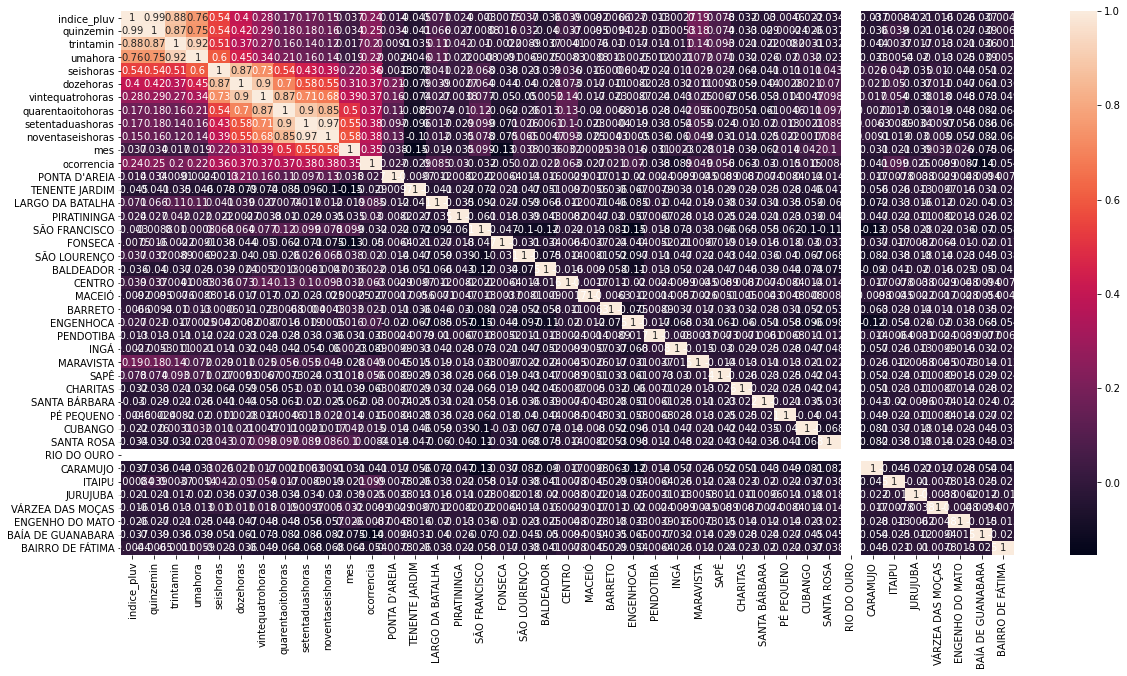

In [13]:
plt.figure(figsize=(20,10))
sns.heatmap(df_treino.corr(),annot=True)

In [16]:
print(get_top_abs_correlations(df_treino, 30))

indice_pluv        quinzemin            0.991385
setentaduashoras   noventaseishoras     0.969267
trintamin          umahora              0.922152
quarentaoitohoras  setentaduashoras     0.900059
dozehoras          vintequatrohoras     0.898463
indice_pluv        trintamin            0.879370
quinzemin          trintamin            0.872767
seishoras          dozehoras            0.872756
vintequatrohoras   quarentaoitohoras    0.866245
quarentaoitohoras  noventaseishoras     0.849157
indice_pluv        umahora              0.756812
quinzemin          umahora              0.749323
seishoras          vintequatrohoras     0.731435
vintequatrohoras   setentaduashoras     0.714945
dozehoras          quarentaoitohoras    0.703116
vintequatrohoras   noventaseishoras     0.676364
umahora            seishoras            0.602608
noventaseishoras   mes                  0.582268
dozehoras          setentaduashoras     0.576785
setentaduashoras   mes                  0.554976
dozehoras          n

# Balanceamento

In [17]:
from imblearn.over_sampling import RandomOverSampler 
oversample = RandomOverSampler(random_state=42)
X_over, y_over = oversample.fit_resample(df_treino, y_treino)

# Modelagem: Modelo Logístico

Obs: Stepwise tem apenas no R

In [25]:
import os
directory = os.getcwd()

In [26]:
df_teste.to_csv(directory+'\dados_teste.csv', index=False)

In [18]:
X_over.to_csv(directory+'\dados_stepwise.csv', index=False)

NameError: name 'directory' is not defined

In [ ]:
#Melhor modelo pelo Stepwise


#Call:
#glm(formula = ocorrencia ~ noventaseishoras + seishoras + mes + 
#    BAÃ.A.DE.GUANABARA + quinzemin + indice_pluv + INGÃ. + SÃƒO.FRANCISCO + 
#    LARGO.DA.BATALHA + CARAMUJO + SANTA.ROSA + CHARITAS + PÃ..PEQUENO + 
#    BAIRRO.DE.FÃ.TIMA + SÃƒO.LOURENÃ.O + SANTA.BÃ.RBARA, family = binomial(link = "logit"), 
#    data = dados)
#
#Deviance Residuals:
#     Min        1Q    Median        3Q       Max  
#-2.58323  -0.80740  -0.07413   0.82969   2.33935  
#
#Coefficients:
#                     Estimate Std. Error z value Pr(>|z|)    
#(Intercept)        -1.2957133  0.1571451  -8.245  < 2e-16 ***
#noventaseishoras    0.0081653  0.0016216   5.035 4.77e-07 ***
#seishoras           0.0265822  0.0068008   3.909 9.28e-05 ***
#mes                 0.0057735  0.0008552   6.751 1.47e-11 ***
#BAÃ.A.DE.GUANABARA -3.3882241  1.0448353  -3.243 0.001183 ** 
#quinzemin           4.9515264  2.0663819   2.396 0.016565 *  
#indice_pluv        -4.5167817  2.0727597  -2.179 0.029323 *  
#INGÃ.              -1.9674385  0.5589435  -3.520 0.000432 ***
#SÃƒO.FRANCISCO     -0.9120897  0.2171672  -4.200 2.67e-05 ***
#LARGO.DA.BATALHA    0.5191743  0.3270380   1.588 0.112398    
#CARAMUJO           -0.8299333  0.2641174  -3.142 0.001676 ** 
#SANTA.ROSA         -0.7885052  0.2970927  -2.654 0.007953 ** 
#CHARITAS           -1.0412731  0.4519408  -2.304 0.021222 *  
#PÃ..PEQUENO        -1.0916156  0.4739231  -2.303 0.021259 *  
#BAIRRO.DE.FÃ.TIMA  -0.9535669  0.5440844  -1.753 0.079669 .  
#SÃƒO.LOURENÃ.O     -0.5353618  0.2906909  -1.842 0.065521 .  
#SANTA.BÃ.RBARA     -0.8201544  0.5499279  -1.491 0.135860    
#---
#Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
#
#(Dispersion parameter for binomial family taken to be 1)
#
#    Null deviance: 1641.4  on 1183  degrees of freedom
#Residual deviance: 1226.5  on 1167  degrees of freedom
#AIC: 1260.5
#
#Number of Fisher Scoring iterations: 6

quinzemin e indice_pluv possuem coeficientes muito importantes para a probabilidade, e são variáveis muito correlacionadas. O ideal é fazer dois modelos distintos, um com cada e verificar AIC

In [19]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [24]:
modelo1 = smf.glm(formula='ocorrencia ~ noventaseishoras + seishoras + mes +  BAÍA DE GUANABARA + quinzemin + INGÁ + SÃO FRANCISCO + LARGO DA BATALHA + CARAMUJO + SANTA ROSA + CHARITAS + PÉ PEQUENO + BAIRRO DE FÁTIMA + SÃO LOURENÇO ', data=X_over,
                family = sm.families.Binomial()).fit()

print(modelo1.summary())
print(modelo1.aic)

SyntaxError: invalid syntax (<unknown>, line 1)

# Avaliação